#  Parallel (and Vectorized) Matrix Multiplication

**Author:** Juan Diego González Noguera  
**Date:** December 2024  
**System:** AMD Ryzen 5 7520U (4 cores, 8 threads), Windows 11 and 16 GB of RAM

## 1. Importar Librerías y Cargar Datos

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Tamaño de figuras
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("✓ Librerías cargadas")

✓ Librerías cargadas


In [12]:
# Buscar el archivo CSV más reciente
csv_files = sorted(Path('.').glob('benchmark_results_20251206_165246.csv'), reverse=True)

if csv_files:
    csv_file = str(csv_files[0])
    print(f"📁 Cargando: {csv_file}")
else:
    # O especifica el archivo manualmente
    csv_file = 'benchmark_results_20251206_165246.csv'
    print(f"📁 Intentando cargar: {csv_file}")

# Cargar datos
df = pd.read_csv(csv_file)
df = df[df['success'] == True]  # Solo resultados exitosos

print(f"\n✓ Datos cargados: {len(df)} registros")
print(f"  Tamaños: {sorted(df['size'].unique())}")
print(f"  Métodos: {len(df['method'].unique())}")

df.head()

📁 Cargando: benchmark_results_20251206_165246.csv

✓ Datos cargados: 39 registros
  Tamaños: [100, 200, 500, 1000]
  Métodos: 10


,method,execution_time,memory_used,success,size,threads,processes
0,Básico (secuencial),0.613183,0.074219,True,100,1.0,1.0
1,Threading (2 threads),0.590808,0.007812,True,100,2.0,NaN
2,Threading (4 threads),0.576762,0.101562,True,100,4.0,NaN
3,Threading (8 threads),0.587320,0.003906,True,100,8.0,NaN
4,Multiprocessing (2 procesos),1.790209,1.167969,True,100,NaN,2.0


## 2. Exploración Inicial de Datos

In [13]:
# Estadísticas descriptivas
print("📊 Estadísticas de Tiempo de Ejecución:")
print(df['execution_time'].describe())

print("\n📊 Estadísticas de Memoria:")
print(df['memory_used'].describe())

📊 Estadísticas de Tiempo de Ejecución:
count     39.000000
mean      75.325144
std      164.401380
min        0.000232
25%        0.432739
50%        3.527388
75%       53.894675
max      601.568105
Name: execution_time, dtype: float64

📊 Estadísticas de Memoria:
count    39.000000
mean      3.823317
std      10.522444
min       0.000000
25%       0.021484
50%       1.167969
75%       2.457031
max      65.214844
Name: memory_used, dtype: float64


In [14]:
# Resumen por método
summary = df.groupby('method').agg({
    'execution_time': ['mean', 'std', 'min', 'max'],
    'memory_used': ['mean', 'max']
}).round(4)

print("📊 Resumen por Método:")
summary

📊 Resumen por Método:


execution_time                              \
                                         mean       std     min       max   
method                                                                      
Básico (secuencial)                   24.3437   37.9183  0.6132   68.0750   
Multiprocessing (2 procesos)         105.9727  182.0911  1.7902  377.8778   
Multiprocessing (4 procesos)          69.9575  118.4356  2.0038  246.7414   
Multiprocessing (8 procesos)          51.2895   82.1173  2.8268  173.5230   
NumPy (vectorizado + paralelo)         0.0080    0.0123  0.0002    0.0262   
Numba paralelo (JIT + prange)          0.2459    0.3012  0.0014    0.6552   
Numba vectorizado (JIT + dot)          0.4656    0.6324  0.0133    1.4003   
Threading (2 threads)                169.0197  290.0807  0.5908  601.5681   
Threading (4 threads)                160.6001  269.8323  0.5768  562.0658   
Threading (8 threads)                158.6033  269.5373  0.5873  560.1581   

                               memory_used           
                                      mean      max  
method                                               
Básico (secuencial)                 0.7409   1.8477  
Multiprocessing (2 procesos)        0.8652   1.3008  
Multiprocessing (4 procesos)        1.8447   5.4492  
Multiprocessing (8 procesos)        2.4707   8.0117  
NumPy (vectorizado + paralelo)      3.5361  10.6523  
Numba paralelo (JIT + prange)      18.7588  65.2148  
Numba vectorizado (JIT + dot)       3.9268   7.6953  
Threading (2 threads)               2.3887   7.6328  
Threading (4 threads)               2.4170   7.6328  
Threading (8 threads)               0.5137   2.0391

## 3. Cálculo de Métricas: Speedup y Eficiencia

In [15]:
# Calcular speedup
df['speedup'] = np.nan

for size in df['size'].unique():
    size_mask = df['size'] == size
    size_data = df[size_mask]
    
    # Baseline: método básico o el más lento
    baseline = size_data[size_data['method'] == 'Básico (secuencial)']
    if not baseline.empty:
        baseline_time = baseline['execution_time'].values[0]
    else:
        baseline_time = size_data['execution_time'].max()
    
    df.loc[size_mask, 'speedup'] = baseline_time / df.loc[size_mask, 'execution_time']

print("✓ Speedup calculado")

# Calcular eficiencia
df['efficiency'] = np.nan

# Threading
threading_mask = df['method'].str.contains('Threading', na=False)
if 'threads' in df.columns:
    df.loc[threading_mask, 'efficiency'] = df.loc[threading_mask, 'speedup'] / df.loc[threading_mask, 'threads']

# Multiprocessing
mp_mask = df['method'].str.contains('Multiprocessing', na=False)
if 'processes' in df.columns:
    df.loc[mp_mask, 'efficiency'] = df.loc[mp_mask, 'speedup'] / df.loc[mp_mask, 'processes']

print("✓ Eficiencia calculada")

# Mostrar tabla con métricas
df[['method', 'size', 'execution_time', 'speedup', 'efficiency']].head(15)

✓ Speedup calculado
✓ Eficiencia calculada


,method,size,execution_time,speedup,efficiency
0,Básico (secuencial),100,0.613183,1.000000,NaN
1,Threading (2 threads),100,0.590808,1.037872,0.518936
2,Threading (4 threads),100,0.576762,1.063147,0.265787
3,Threading (8 threads),100,0.587320,1.044036,0.130505
4,Multiprocessing (2 procesos),100,1.790209,0.342520,0.171260
5,Multiprocessing (4 procesos),100,2.003815,0.306008,0.076502
6,Multiprocessing (8 procesos),100,2.826832,0.216915,0.027114
7,NumPy (vectorizado + paralelo),100,0.000232,2640.753843,NaN
8,Numba paralelo (JIT + prange),100,0.655186,0.935892,NaN
9,Numba vectorizado (JIT + dot),100,0.274171,2.236500,NaN


## 4. Visualizaciones

### 4.1 Tiempo de Ejecución vs Tamaño

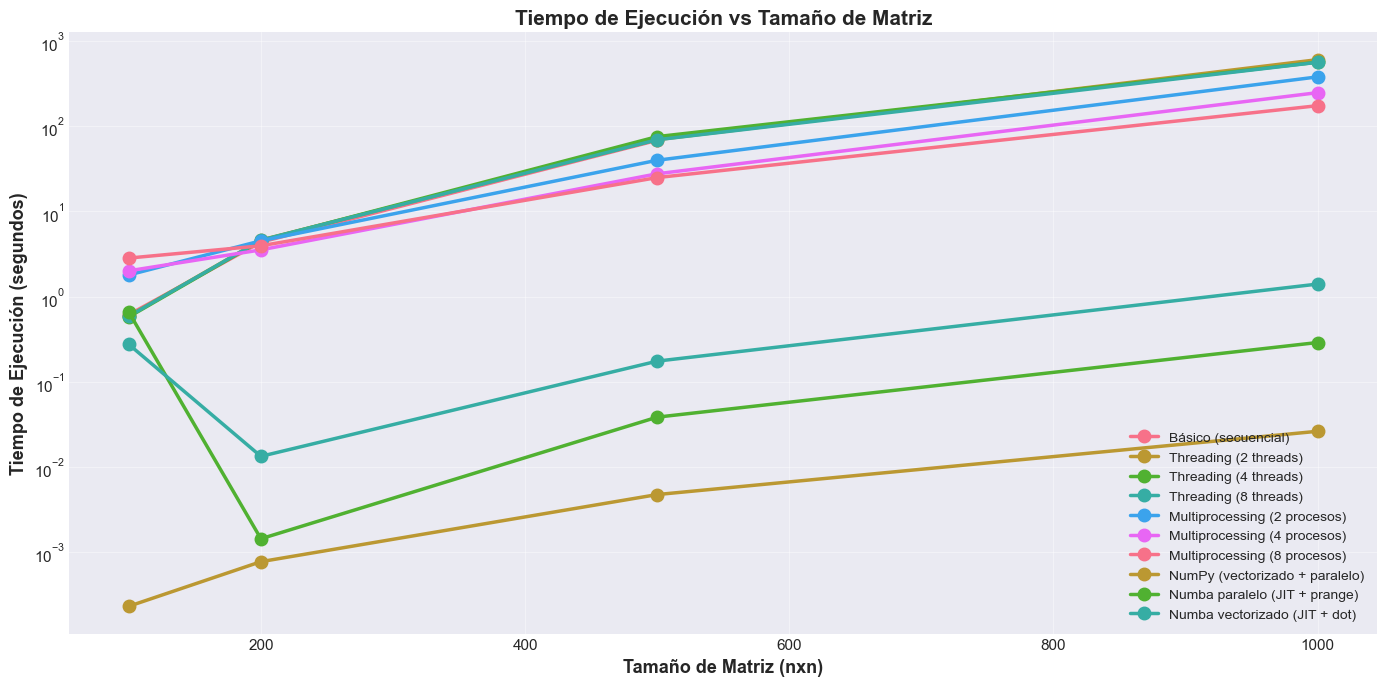

In [16]:
plt.figure(figsize=(14, 7))

for method in df['method'].unique():
    method_data = df[df['method'] == method].sort_values('size')
    plt.plot(method_data['size'], method_data['execution_time'],
            marker='o', linewidth=2.5, markersize=9, label=method)

plt.xlabel('Tamaño de Matriz (nxn)', fontsize=13, fontweight='bold')
plt.ylabel('Tiempo de Ejecución (segundos)', fontsize=13, fontweight='bold')
plt.title('Tiempo de Ejecución vs Tamaño de Matriz', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.4)
plt.yscale('log')
plt.tight_layout()
plt.show()

### 4.2 Speedup vs Tamaño

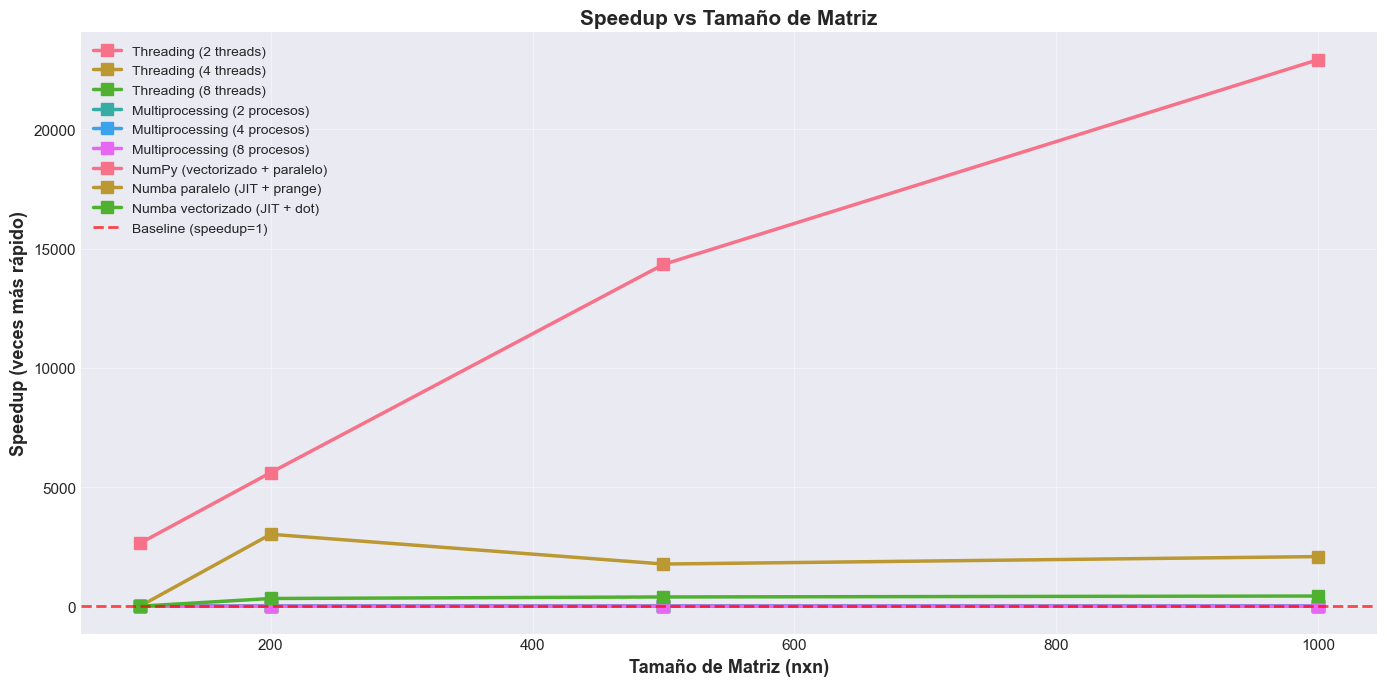

In [17]:
plt.figure(figsize=(14, 7))

# Excluir método básico
df_speedup = df[df['method'] != 'Básico (secuencial)'].copy()

for method in df_speedup['method'].unique():
    method_data = df_speedup[df_speedup['method'] == method].sort_values('size')
    plt.plot(method_data['size'], method_data['speedup'],
            marker='s', linewidth=2.5, markersize=9, label=method)

plt.axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Baseline (speedup=1)')

plt.xlabel('Tamaño de Matriz (nxn)', fontsize=13, fontweight='bold')
plt.ylabel('Speedup (veces más rápido)', fontsize=13, fontweight='bold')
plt.title('Speedup vs Tamaño de Matriz', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### 4.3 Comparación de Métodos (Último Tamaño)

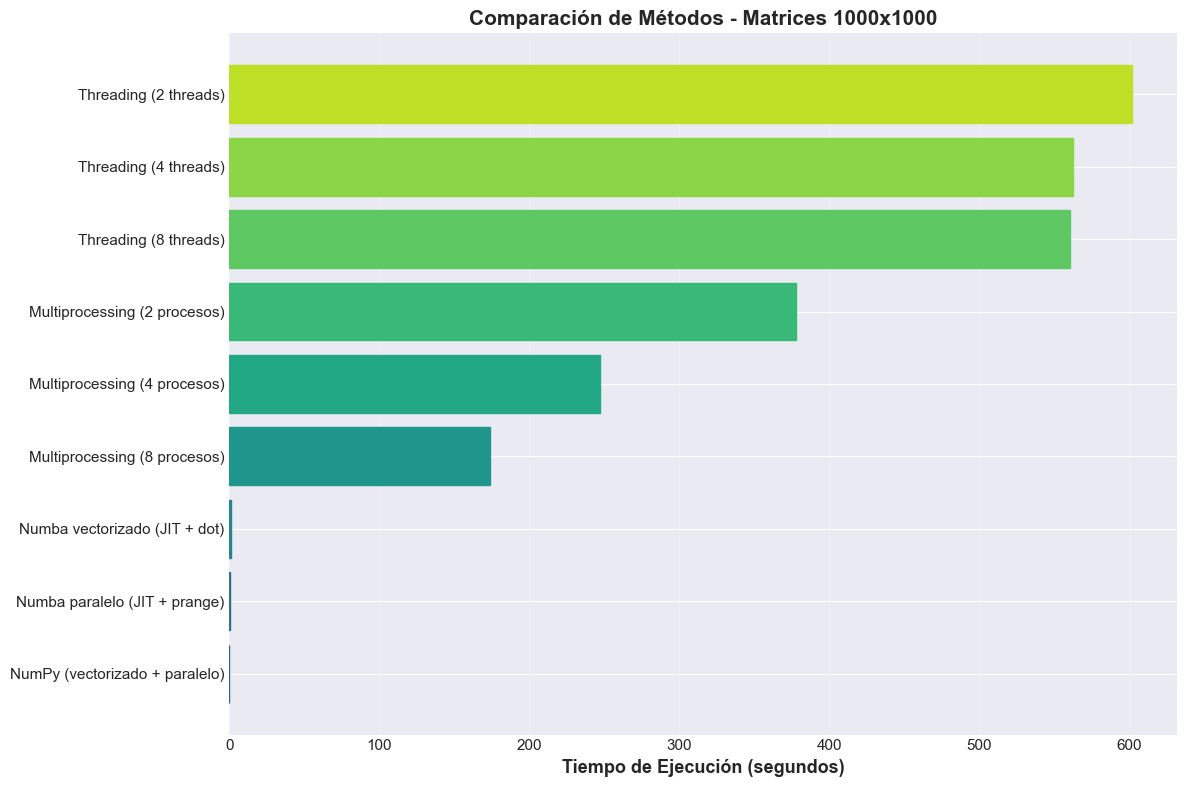


🏆 Método más rápido para 1000x1000:
   NumPy (vectorizado + paralelo): 0.0262s


In [18]:
# Obtener el tamaño más grande
max_size = df['size'].max()
df_max = df[df['size'] == max_size].sort_values('execution_time')

plt.figure(figsize=(12, 8))
bars = plt.barh(df_max['method'], df_max['execution_time'])

# Colorear barras
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(bars)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

plt.xlabel('Tiempo de Ejecución (segundos)', fontsize=13, fontweight='bold')
plt.title(f'Comparación de Métodos - Matrices {max_size}x{max_size}', 
         fontsize=15, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print(f"\n🏆 Método más rápido para {max_size}x{max_size}:")
print(f"   {df_max.iloc[0]['method']}: {df_max.iloc[0]['execution_time']:.4f}s")

### 4.4 Heatmap de Tiempos

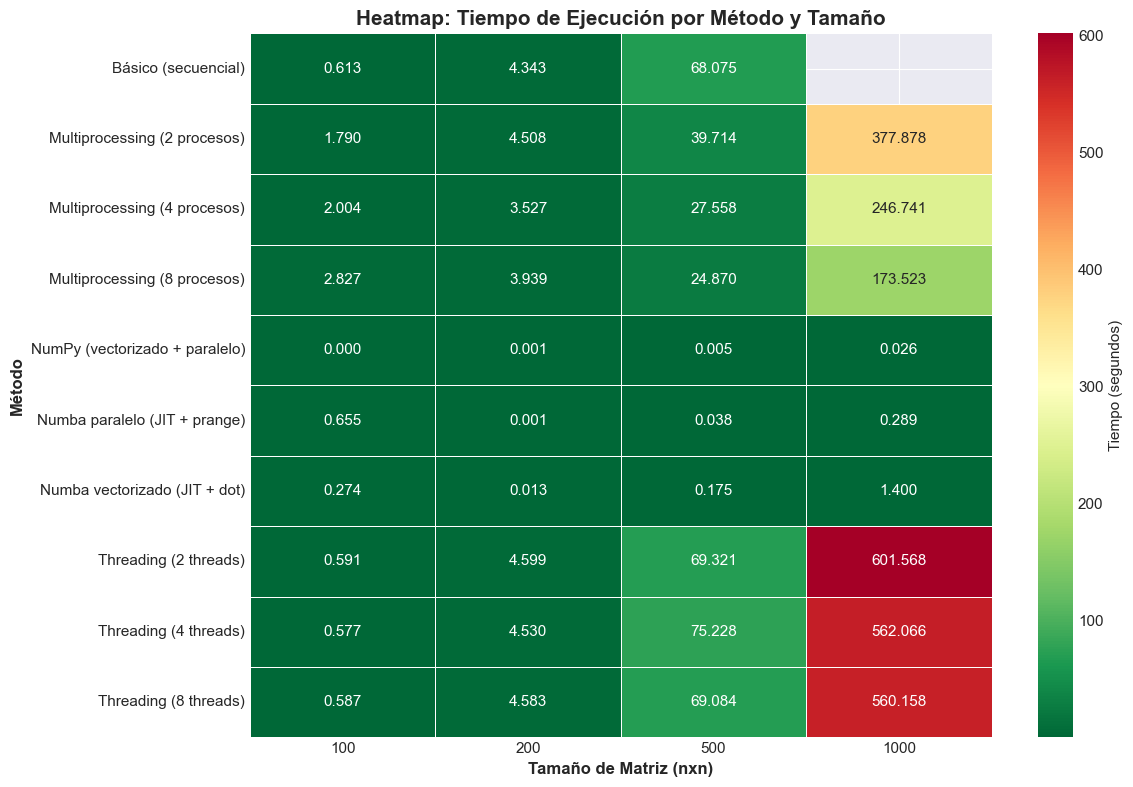

In [19]:
# Crear pivot table
pivot = df.pivot_table(values='execution_time', index='method', columns='size', aggfunc='mean')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn_r', 
           cbar_kws={'label': 'Tiempo (segundos)'}, linewidths=0.5)
plt.title('Heatmap: Tiempo de Ejecución por Método y Tamaño', 
         fontsize=15, fontweight='bold')
plt.xlabel('Tamaño de Matriz (nxn)', fontsize=12, fontweight='bold')
plt.ylabel('Método', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.5 Eficiencia de Paralelización

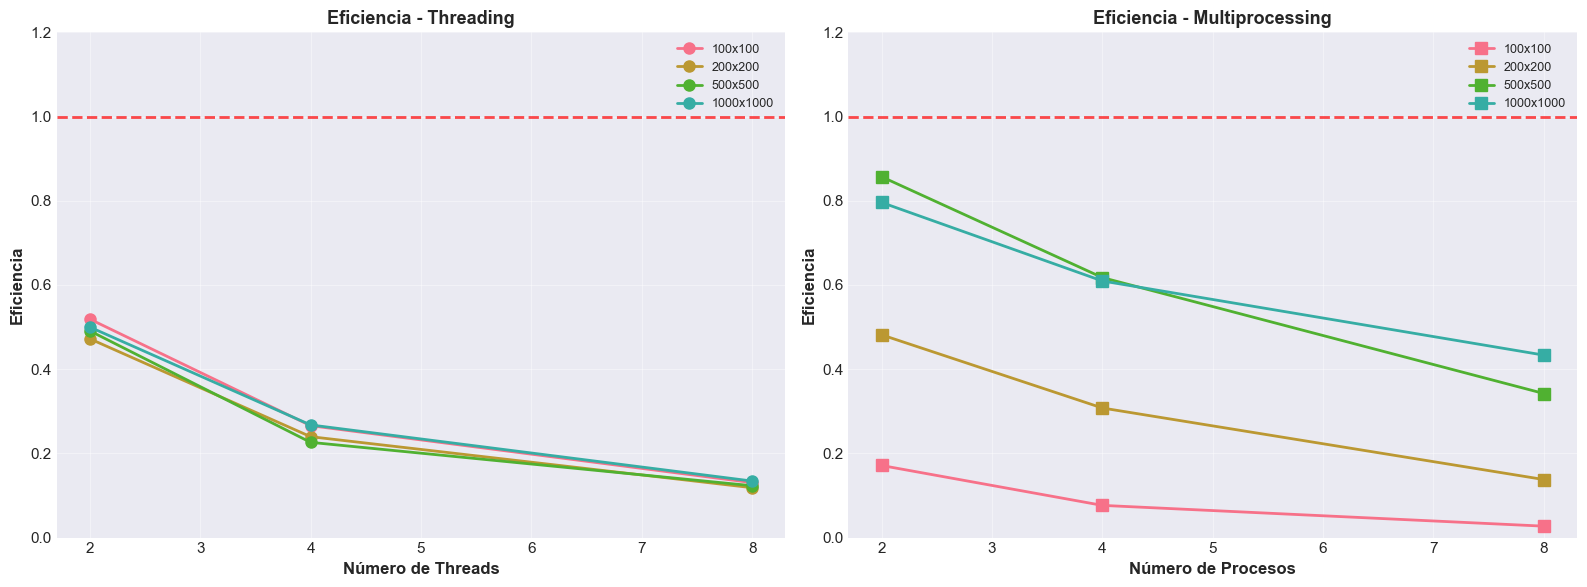

In [20]:
# Filtrar datos con eficiencia
df_eff = df[df['efficiency'].notna()].copy()

if not df_eff.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Threading
    threading = df_eff[df_eff['method'].str.contains('Threading', na=False)]
    if not threading.empty:
        for size in sorted(threading['size'].unique()):
            size_data = threading[threading['size'] == size].sort_values('threads')
            axes[0].plot(size_data['threads'], size_data['efficiency'],
                       marker='o', linewidth=2, markersize=8, label=f'{size}x{size}')
        
        axes[0].axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7)
        axes[0].set_xlabel('Número de Threads', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Eficiencia', fontsize=12, fontweight='bold')
        axes[0].set_title('Eficiencia - Threading', fontsize=13, fontweight='bold')
        axes[0].legend(fontsize=9)
        axes[0].grid(True, alpha=0.4)
        axes[0].set_ylim(0, 1.2)
    
    # Multiprocessing
    mp = df_eff[df_eff['method'].str.contains('Multiprocessing', na=False)]
    if not mp.empty:
        for size in sorted(mp['size'].unique()):
            size_data = mp[mp['size'] == size].sort_values('processes')
            axes[1].plot(size_data['processes'], size_data['efficiency'],
                       marker='s', linewidth=2, markersize=8, label=f'{size}x{size}')
        
        axes[1].axhline(y=1, color='red', linestyle='--', linewidth=2, alpha=0.7)
        axes[1].set_xlabel('Número de Procesos', fontsize=12, fontweight='bold')
        axes[1].set_ylabel('Eficiencia', fontsize=12, fontweight='bold')
        axes[1].set_title('Eficiencia - Multiprocessing', fontsize=13, fontweight='bold')
        axes[1].legend(fontsize=9)
        axes[1].grid(True, alpha=0.4)
        axes[1].set_ylim(0, 1.2)
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No hay datos de eficiencia disponibles")

### 4.6 Uso de Memoria

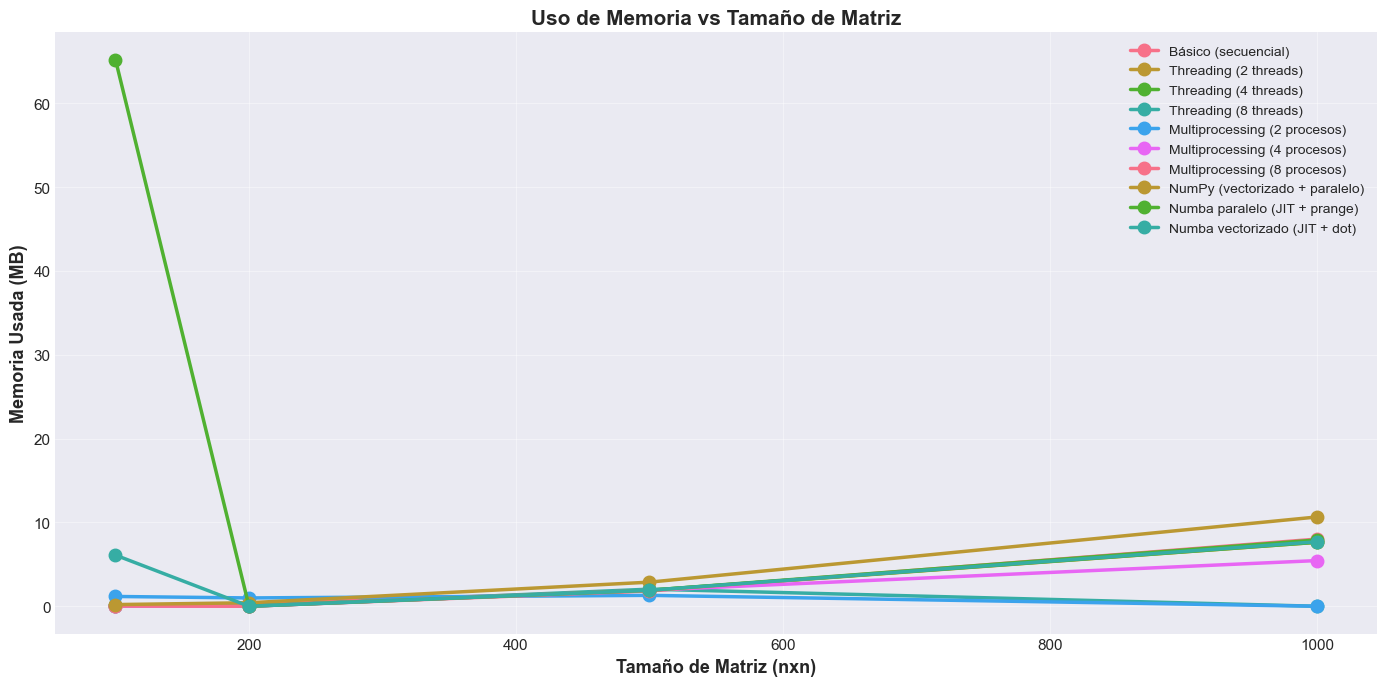

In [21]:
plt.figure(figsize=(14, 7))

for method in df['method'].unique():
    method_data = df[df['method'] == method].sort_values('size')
    plt.plot(method_data['size'], method_data['memory_used'],
            marker='o', linewidth=2.5, markersize=9, label=method)

plt.xlabel('Tamaño de Matriz (nxn)', fontsize=13, fontweight='bold')
plt.ylabel('Memoria Usada (MB)', fontsize=13, fontweight='bold')
plt.title('Uso de Memoria vs Tamaño de Matriz', fontsize=15, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

## 5. Análisis Estadístico

In [22]:
print("📊 TOP 5 MÉTODOS MÁS RÁPIDOS (Promedio):")
print("="*60)

avg_times = df.groupby('method')['execution_time'].mean().sort_values()
for i, (method, time) in enumerate(avg_times.head().items(), 1):
    print(f"{i}. {method:45s}: {time:8.4f}s")

print(f"\n🏆 GANADOR: {avg_times.index[0]}")
print(f"   Tiempo promedio: {avg_times.values[0]:.4f}s")

📊 TOP 5 MÉTODOS MÁS RÁPIDOS (Promedio):
1. NumPy (vectorizado + paralelo)               :   0.0080s
2. Numba paralelo (JIT + prange)                :   0.2459s
3. Numba vectorizado (JIT + dot)                :   0.4656s
4. Básico (secuencial)                          :  24.3437s
5. Multiprocessing (8 procesos)                 :  51.2895s

🏆 GANADOR: NumPy (vectorizado + paralelo)
   Tiempo promedio: 0.0080s


In [23]:
print("📊 MEJOR SPEEDUP ALCANZADO:")
print("="*60)

if 'speedup' in df.columns and df['speedup'].notna().any():
    best_speedup = df.loc[df['speedup'].idxmax()]
    print(f"Método: {best_speedup['method']}")
    print(f"Tamaño: {best_speedup['size']}x{best_speedup['size']}")
    print(f"Speedup: {best_speedup['speedup']:.2f}x")
    print(f"Tiempo: {best_speedup['execution_time']:.4f}s")

📊 MEJOR SPEEDUP ALCANZADO:
Método: NumPy (vectorizado + paralelo)
Tamaño: 1000x1000
Speedup: 22929.11x
Tiempo: 0.0262s


In [24]:
print("📊 COMPARACIÓN THREADING vs MULTIPROCESSING:")
print("="*60)

threading_avg = df[df['method'].str.contains('Threading', na=False)]['execution_time'].mean()
mp_avg = df[df['method'].str.contains('Multiprocessing', na=False)]['execution_time'].mean()

print(f"Threading (promedio):      {threading_avg:.4f}s")
print(f"Multiprocessing (promedio): {mp_avg:.4f}s")
print(f"\nMultiprocessing es {threading_avg/mp_avg:.2f}x más rápido que Threading")

📊 COMPARACIÓN THREADING vs MULTIPROCESSING:
Threading (promedio):      162.7410s
Multiprocessing (promedio): 75.7399s

Multiprocessing es 2.15x más rápido que Threading


## 6. Conclusiones

### Observaciones Clave:

1. **Método más eficiente:** [Completa basándote en tus resultados]

2. **Threading vs Multiprocessing:**
   - Threading: [Observaciones]
   - Multiprocessing: [Observaciones]
   - Razón: GIL (Global Interpreter Lock) de Python

3. **NumPy:**
   - [Observaciones sobre su rendimiento]
   - Razón: Implementación en C/Fortran + BLAS optimizado

4. **Escalabilidad:**
   - [Cómo escala cada método con el tamaño]

5. **Eficiencia de Paralelización:**
   - [Análisis de eficiencia vs número de cores]

### Recomendaciones:

- Para matrices pequeñas (<500x500): [Recomendación]
- Para matrices medianas (500-1500): [Recomendación]
- Para matrices grandes (>1500): [Recomendación]


## 7. Exportar Resultados

In [25]:
# Guardar DataFrame procesado
df.to_csv('benchmark_results_processed.csv', index=False)
print("✓ Resultados procesados guardados en: benchmark_results_processed.csv")

# Guardar resumen
summary_df = df.groupby(['method', 'size']).agg({
    'execution_time': 'mean',
    'speedup': 'mean',
    'efficiency': 'mean',
    'memory_used': 'mean'
}).round(4)

summary_df.to_csv('benchmark_summary.csv')
print("✓ Resumen guardado en: benchmark_summary.csv")

✓ Resultados procesados guardados en: benchmark_results_processed.csv
✓ Resumen guardado en: benchmark_summary.csv
